![logo](../../.././docs/images/Logo_Destination_Earth_Colours.png)

# Lazy Browse — DestinE Climate DT Hourly Portfolio

This notebook explores the **hourly (`clte`) stream** of the Climate DT Generation 2 data portfolio.

**Prerequisites:** run `01_key_destine_once.ipynb` once to authenticate.

In [ ]:
import logging, warnings
import earthkit.data

# Disable earthkit disk cache (polytope_zarr caches decoded arrays in memory)
earthkit.data.config.set("cache-policy", "off")

# Silence verbose output from polytope / earthkit internals
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
from polytope_zarr import PolytopeZarrStore

## 1. Create hourly store

The function `PolytopeZarrStore.from_climate_dt(frequency="hourly")`
automatically selects `PORTFOLIO_GEN2_CLTE`.

In [ ]:
# ── Configuration ─────────────────────────────────────────────────

# ── Choose a levtype (uncomment one) ──────────────────────────────
LEVTYPE = "sfc"                    # 34 vars — surface (14 instant + 20 hourly mean)
# LEVTYPE = "pl"                   #  9 vars — pressure levels (19 levels)
# LEVTYPE = "hl"                   #  2 vars — height levels (100 m, IFS-only)
# LEVTYPE = "sol"                  #  2 vars — soil / snow
# LEVTYPE = "o2d"                  # 12 vars — 2-D ocean & sea ice (daily)
# LEVTYPE = "o3d"                  #  5 vars — 3-D ocean (daily, up to 75 levels)

store = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment="hist",
    resolution="standard", # 'standard', 'high'
    levtype=LEVTYPE,
    frequency="hourly",
    start_date="1990-01-01T00:00:00",
    end_date="2014-12-31T23:00:00",
)
print(store)

<PolytopeZarrStore 34 variables (time=219144, cell=196608, model=3)>


## 2. Open as xarray Dataset — lazy browse

In [ ]:
ds = store.open()
ds

<xarray.Dataset> Size: 18TB
Dimensions:       (model: 3, time: 219144, cell: 196608)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 2MB 1990-01-01 ... 2014-12-31T23:00:00
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    10si          (model, time, cell) float32 517GB ...
    10u           (model, time, cell) float32 517GB ...
    10v           (model, time, cell) float32 517GB ...
    2d            (model, time, cell) float32 517GB ...
    2t            (model, time, cell) float32 517GB ...
    avg_ie        (model, time, cell) float32 517GB ...
    ...            ...
    sp            (model, time, cell) float32 517GB ...
    tcc           (model, time, cell) float32 517GB ...
    tciw          (model, time, cell) float32 517GB ...
    tclw          (model, time, cell) float32 517GB ...
    tcw           (model, time, cell) float32 517GB ...
    tcwv          (model, time, cell) float32 517GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=219144, cell=1966...

## 3. Plot a single hourly field (triggers lazy fetch)

Only now does the store actually call Polytope — fetching data for the
selected model, time, and variable.

In [ ]:
import healpy as hp
import matplotlib.pyplot as plt

field = ds["2t"].sel(model="IFS-FESOM", time="2014-01-01T12:00")
print(f"Fetching {dict(field.sizes)} values...")
values = field.values  # triggers the Polytope request

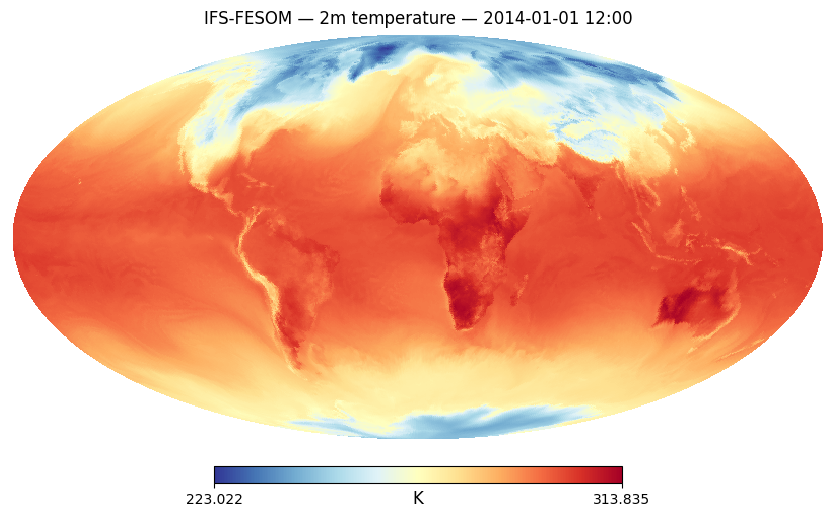

In [ ]:
hp.mollview(values, title="IFS-FESOM — 2m temperature — 2014-01-01 12:00",
            unit="K", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

In [ ]:
#annual mean, can take around 6-10 minutes depending on your connection
field2 = ds["avg_tprate"].polytope.sel(model="IFS-FESOM", time=slice("2014-01-01T00:00", "2014-12-31T23:00")).mean("time")
field2_values_mean = field2.values  # triggers the Polytope request

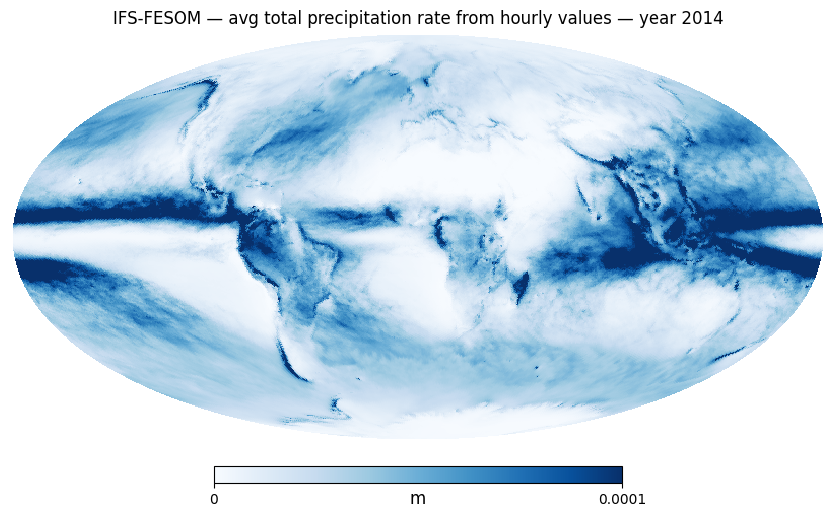

In [ ]:
hp.mollview(field2_values_mean,
            title="IFS-FESOM — avg total precipitation rate from hourly values — year 2014",
            unit="m", cmap="Blues", min=0, max=0.0001, nest=True, flip='geo')
plt.show()

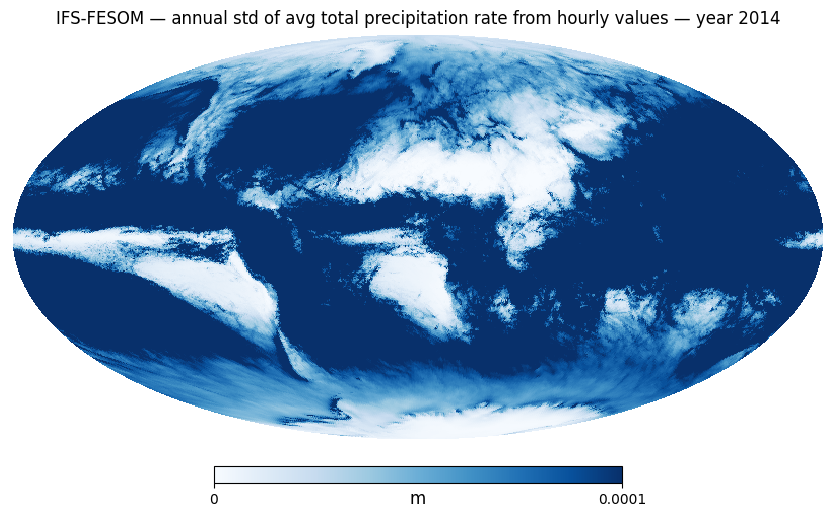

In [ ]:
# in the next call, the data is read from cache, and we can apply a different reduction (std instead of mean) without re-reading the data
field2 = ds["avg_tprate"].sel(model="IFS-FESOM", time=slice("2014-01-01T00:00", "2014-12-31T23:00")).std("time")

hp.mollview(field2.values,
            title="IFS-FESOM — annual std of avg total precipitation rate from hourly values — year 2014",
            unit="m", cmap="Blues", min=0, max=0.0001, nest=True, flip='geo')
plt.show()

# Create a daily ocean store

In [ ]:
# ── Configuration ─────────────────────────────────────────────────
LEVTYPE = "o2d"

daily_store = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment="hist",
    levtype=LEVTYPE,
    frequency="hourly",
    start_date="1990-01-01",
    end_date="2014-12-31",
)
print(daily_store)

<PolytopeZarrStore 12 variables (time=9131, cell=196608, model=3)>


In [ ]:
ds_oce = daily_store.open()
ds_oce

<xarray.Dataset> Size: 259GB
Dimensions:      (model: 3, time: 9131, cell: 196608)
Coordinates:
  * model        (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time         (time) datetime64[ns] 73kB 1990-01-01 1990-01-02 ... 2014-12-31
  * cell         (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables:
    avg_hc300m   (model, time, cell) float32 22GB ...
    avg_hc700m   (model, time, cell) float32 22GB ...
    avg_hcbtm    (model, time, cell) float32 22GB ...
    avg_siconc   (model, time, cell) float32 22GB ...
    avg_sithick  (model, time, cell) float32 22GB ...
    avg_siue     (model, time, cell) float32 22GB ...
    avg_sivn     (model, time, cell) float32 22GB ...
    avg_sivol    (model, time, cell) float32 22GB ...
    avg_snvol    (model, time, cell) float32 22GB ...
    avg_sos      (model, time, cell) float32 22GB ...
    avg_tos      (model, time, cell) float32 22GB ...
    avg_zos      (model, time, cell) float32 22GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 12 variables (time=9131, cell=196608...

In [ ]:
import healpy as hp
import matplotlib.pyplot as plt

ocefield = ds_oce["avg_zos"].sel(model="IFS-NEMO", time="2014-01-01")
print(f"Fetching {dict(ocefield.sizes)} values...")
ocefield_values = ocefield.values  # triggers the Polytope request

In [ ]:
hp.mollview(ocefield_values, title="IFS-NEMO — Sea Surface Height — 2014-01-01",
            unit="m", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

# Create an hourly storyline store (story-nudging)

The storylines use `activity="story-nudging"` and experiments are `cont` (pre-industrial climate), `hist` (present-day climate), and `Tplus2.0K` (+2K warmer world).
The dataset dimension is `climate` (not `model`).

> **See also:** [climate-dt-earthkit-fe-story-nudging.ipynb](../feature-extraction/climate-dt-earthkit-fe-story-nudging.ipynb)

In [ ]:
story_store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-FESOM"],
    experiment=["cont", "hist", "Tplus2.0K"],
    activity="story-nudging",
    levtype="sfc",
    frequency="hourly",
    start_date="2017-01-01T00:00:00",
    end_date="2024-12-31T23:00:00",
    resolution="standard",
)
print(story_store)

<PolytopeZarrStore 34 variables (time=70128, cell=196608, climate=3)>


In [ ]:
ds_story = story_store.open()
ds_story

<xarray.Dataset> Size: 6TB
Dimensions:       (climate: 3, time: 70128, cell: 196608)
Coordinates:
  * climate       (climate) object 24B 'cont' 'hist' 'Tplus2.0K'
  * time          (time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T23:00:00
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    10si          (climate, time, cell) float32 165GB ...
    10u           (climate, time, cell) float32 165GB ...
    10v           (climate, time, cell) float32 165GB ...
    2d            (climate, time, cell) float32 165GB ...
    2t            (climate, time, cell) float32 165GB ...
    avg_ie        (climate, time, cell) float32 165GB ...
    ...            ...
    sp            (climate, time, cell) float32 165GB ...
    tcc           (climate, time, cell) float32 165GB ...
    tciw          (climate, time, cell) float32 165GB ...
    tclw          (climate, time, cell) float32 165GB ...
    tcw           (climate, time, cell) float32 165GB ...
    tcwv          (climate, time, cell) float32 165GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=70128, cell=19660...

Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...
Fetching {'cell': 196608} values...


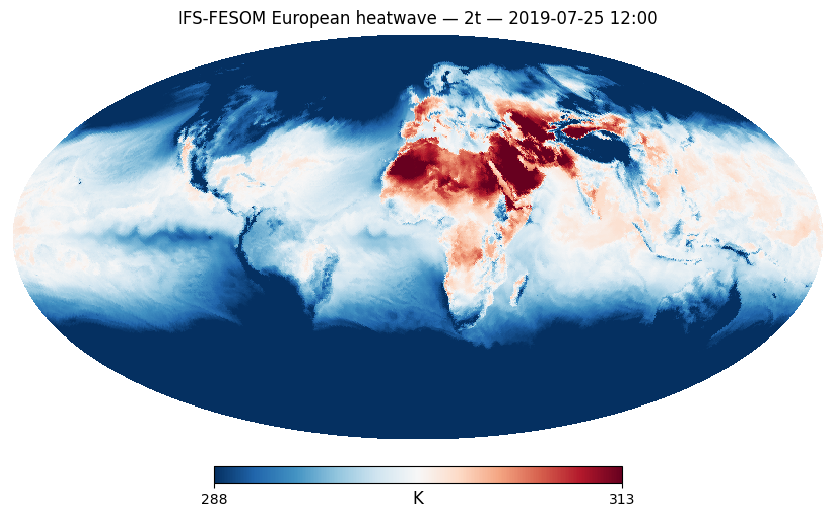

In [ ]:
# Note: look at Paris heatwave on 2019-07-25
field_story_PI = ds_story["2t"].sel(climate="cont", time="2019-07-25T12:00")
print(f"Fetching {dict(field_story_PI.sizes)} values...")

field_story_PD = ds_story["2t"].sel(climate="hist", time="2019-07-25T12:00")
print(f"Fetching {dict(field_story_PD.sizes)} values...")

field_story_2K = ds_story["2t"].sel(climate="Tplus2.0K", time="2019-07-25T12:00")
print(f"Fetching {dict(field_story_2K.sizes)} values...")

hp.mollview(field_story_PD.values, title="IFS-FESOM European heatwave — 2t — 2019-07-25 12:00",
            unit="K", cmap="RdBu_r", nest=True, flip="geo", min=288, max=313)
plt.show()

# Server-side spatial subsetting (Polytope features)

`.polytope.sel()` also supports **server-side spatial extraction** via the
Polytope feature API.  Pass `bbox` or `polygon` to retrieve only a smaller subset of HEALPix cells, or `point` to get only a timeseries at a single point.

## Feature extraction — timeseries (hourly)

Hourly timeseries uses `point=(lat, lon)` and returns CoverageJSON.
The response contains hourly time coordinates and field values for plotting.

> **See also:** [climate-dt-earthkit-fe-timeseries.ipynb](../feature-extraction/climate-dt-earthkit-fe-timeseries.ipynb) · [climate-dt-earthkit-fe-story-nudging.ipynb](../feature-extraction/climate-dt-earthkit-fe-story-nudging.ipynb) · [climate-dt-train-ai-timeseries-polytope.ipynb](../full-field-post-processing/climate-dt-train-ai-timeseries-polytope.ipynb)

In [ ]:
# Point timeseries — hourly (clte stream)
ts_result = ds["2t"].polytope.sel(
    model="IFS-NEMO",
    time=slice("2014-01-01T00:00", "2014-01-02T23:00"),
    point=(52.5, 13.4),  # Berlin
)
print(type(ts_result))

  🌍 timeseries request for 2t (20140101/to/20140102)


<class 'dict'>


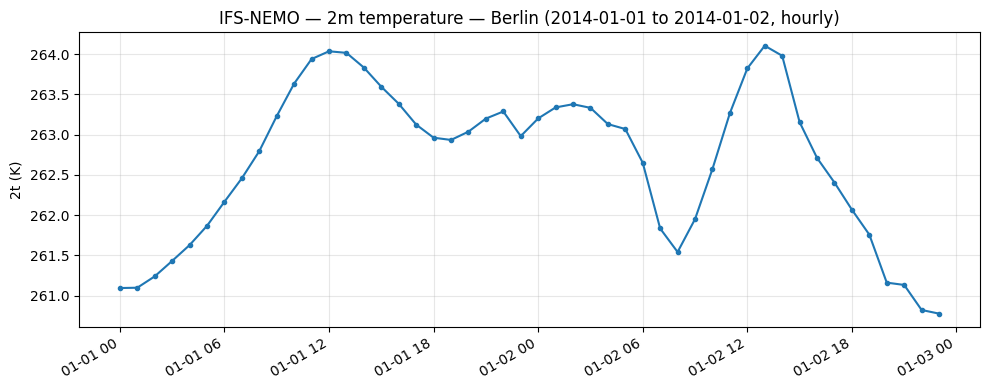

In [ ]:
import pandas as pd

# Extract times and values from CoverageJSON
cov = ts_result["coverages"][0]
times = pd.to_datetime(cov["domain"]["axes"]["t"]["values"])
values = cov["ranges"]["2t"]["values"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values, marker="o", markersize=3)
ax.set_ylabel("2t (K)")
ax.set_title("IFS-NEMO — 2m temperature — Berlin (2014-01-01 to 2014-01-02, hourly)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
# 3x Paris point timeseries for different climates (PI, PD, +2K) — hourly (storyline activity)
ts_story_PI = ds_story["2t"].polytope.sel(
    climate="cont",
    time=slice("2019-07-25T00:00", "2019-07-25T23:00"),
    point=(48.85, 2.35),  # Paris
)
ts_story_PD = ds_story["2t"].polytope.sel(
    climate="hist",
    time=slice("2019-07-25T00:00", "2019-07-25T23:00"),
    point=(48.85, 2.35),  # Paris
)
ts_story_2K = ds_story["2t"].polytope.sel(
    climate="Tplus2.0K",
    time=slice("2019-07-25T00:00", "2019-07-25T23:00"),
    point=(48.85, 2.35),  # Paris
)
print(type(ts_story_PI))
print(type(ts_story_PD))
print(type(ts_story_2K))

  🌍 timeseries request for 2t (20190725/to/20190725)


  🌍 timeseries request for 2t (20190725/to/20190725)


  🌍 timeseries request for 2t (20190725/to/20190725)


<class 'dict'>
<class 'dict'>
<class 'dict'>


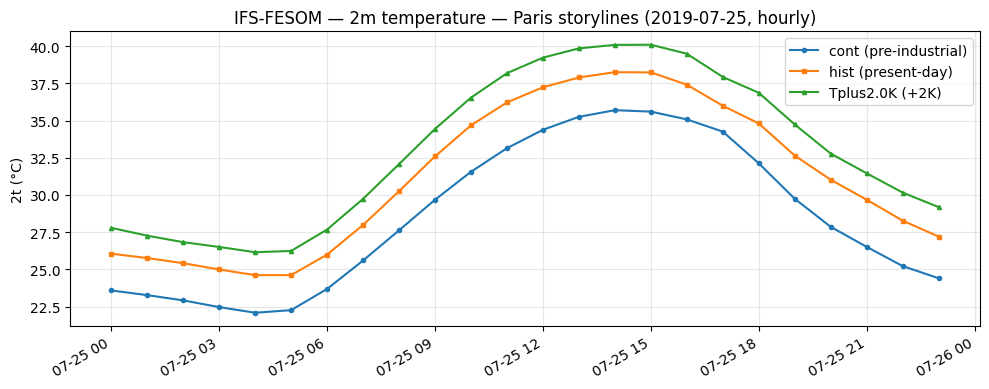

In [ ]:
import pandas as pd
import numpy as np

# Extract times and values from CoverageJSON for each scenario
cov_PI = ts_story_PI["coverages"][0]
times = pd.to_datetime(cov_PI["domain"]["axes"]["t"]["values"])
values_PI = np.array(cov_PI["ranges"]["2t"]["values"])

cov_PD = ts_story_PD["coverages"][0]
values_PD = np.array(cov_PD["ranges"]["2t"]["values"])

cov_2K = ts_story_2K["coverages"][0]
values_2K = np.array(cov_2K["ranges"]["2t"]["values"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values_PI - 273.15, marker="o", markersize=3, label="cont (pre-industrial)")
ax.plot(times, values_PD - 273.15, marker="s", markersize=3, label="hist (present-day)")
ax.plot(times, values_2K - 273.15, marker="^", markersize=3, label="Tplus2.0K (+2K)")
ax.set_ylabel("2t (°C)")
ax.set_title("IFS-FESOM — 2m temperature — Paris storylines (2019-07-25, hourly)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Let's create a high-resolution store with the same parameters, but resolution="high". This will have more pixels and thus more detail in the plot, but will still be just as easy to access thanks to Polytope's efficient server-side subsetting.

In [ ]:
store_high = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment="hist",
    resolution="high", # 'standard', 'high'
    levtype="sfc",
    frequency="hourly",
    start_date="1990-01-01T00:00:00",
    end_date="2014-12-31T23:00:00",
)
print(store_high)

<PolytopeZarrStore 34 variables (time=219144, cell=12582912, model=3)>


In [ ]:
ds_high = store_high.open()
ds_high

<xarray.Dataset> Size: 1PB
Dimensions:       (model: 3, time: 219144, cell: 12582912)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 2MB 1990-01-01 ... 2014-12-31T23:00:00
  * cell          (cell) int32 50MB 0 1 2 3 ... 12582909 12582910 12582911
Data variables: (12/34)
    10si          (model, time, cell) float32 33TB ...
    10u           (model, time, cell) float32 33TB ...
    10v           (model, time, cell) float32 33TB ...
    2d            (model, time, cell) float32 33TB ...
    2t            (model, time, cell) float32 33TB ...
    avg_ie        (model, time, cell) float32 33TB ...
    ...            ...
    sp            (model, time, cell) float32 33TB ...
    tcc           (model, time, cell) float32 33TB ...
    tciw          (model, time, cell) float32 33TB ...
    tclw          (model, time, cell) float32 33TB ...
    tcw           (model, time, cell) float32 33TB ...
    tcwv          (model, time, cell) float32 33TB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=219144, cell=1258...

## Feature extraction — bounding box (native HEALPix)

`bbox=(south, west, north, east)` returns native HEALPix pixels within the bounding box.
The cells below render them as filled polygons using `healpy.boundaries()` — no interpolation needed.

> **See also:** [climate-dt-earthkit-fe-boundingbox.ipynb](../feature-extraction/climate-dt-earthkit-fe-boundingbox.ipynb) · [climate-dt-earthkit-geotiff.ipynb](../full-field-post-processing/climate-dt-earthkit-geotiff.ipynb) (bbox → GeoTIFF)

In [ ]:
# Bounding box — single hour
bbox_result = ds_high["2t"].polytope.sel(
    model="ICON",
    time="2014-01-01T12:00",
    bbox=(47, 5, 55, 15),  # (south, west, north, east)
)
print(type(bbox_result))
bbox_result

  🌍 boundingbox request for 2t (20140101)


<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 615kB
Dimensions:    (time: 1, points: 15363)
Coordinates:
  * time       (time) datetime64[ns] 8B 2014-01-01T12:00:00
  * points     (points) int64 123kB 0 1 2 3 4 ... 15358 15359 15360 15361 15362
    latitude   (points) float64 123kB 47.01 47.01 47.01 ... 54.96 54.96 54.96
    longitude  (points) float64 123kB 14.74 14.54 14.64 ... 14.01 14.25 13.77
    levelist   (points) float64 123kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    2t         (time, points) float64 123kB 273.3 271.3 269.5 ... 280.0 279.6
Attributes: (12/16)
    activity:       baseline
    class:          d1
    dataset:        climate-dt
    Forecast date:  2014-01-01T12:00:00Z
    experiment:     hist
    expver:         0001
    ...             ...
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    step:           0
    date:           2014-01-01T12:00:00Z

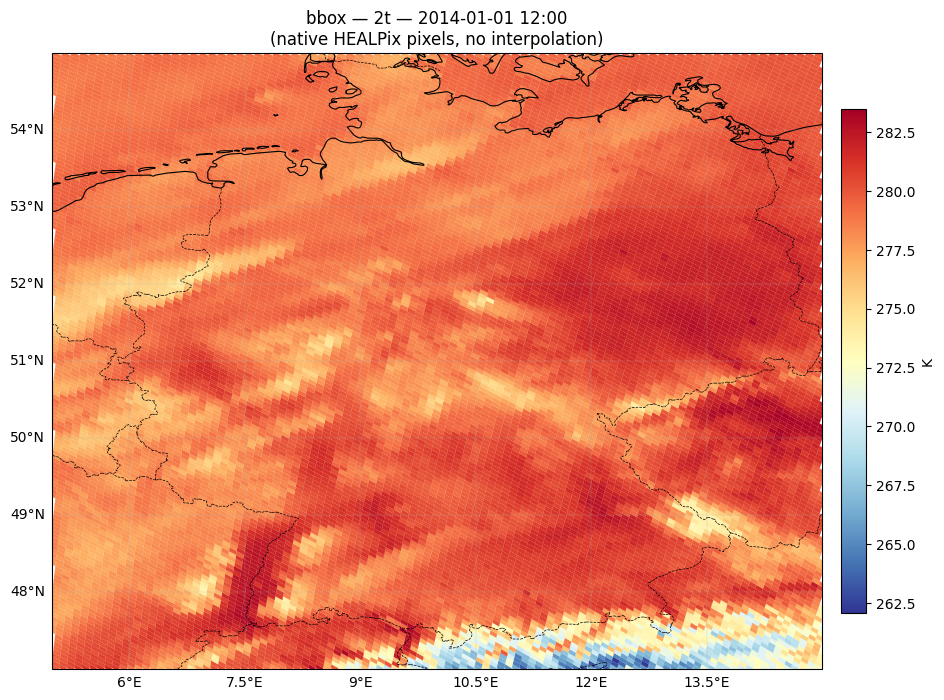

In [ ]:
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors

nside = store_high.nside
da = bbox_result["2t"].squeeze()
lats = bbox_result.coords["latitude"].values
lons = bbox_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

# Get pixel boundary vertices — only for our pixels, not the full sky
n_steps = 50
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

# Convert boundary xyz → lon/lat and build polygon list
polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

# Plot with cartopy — native HEALPix cells, no interpolation
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlBu_r

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(cmap)
coll.set_norm(norm)
ax.add_collection(coll)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([5, 15, 47, 55])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title("bbox — 2t — 2014-01-01 12:00\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

## Feature extraction — polygon (country cut-out)

Uses `earthkit.geo.cartography.country_polygons()` to get the boundary
of any named country, then passes it to the Polytope polygon feature.
Returns native HEALPix cells inside the country shape — no interpolation.

> **See also:** [climate-dt-earthkit-fe-polygon.ipynb](../feature-extraction/climate-dt-earthkit-fe-polygon.ipynb) · [climate-dt-earthkit-fe-country.ipynb](../feature-extraction/climate-dt-earthkit-fe-country.ipynb) · [climate-dt-earthkit-fe-pcolormesh.ipynb](../feature-extraction/climate-dt-earthkit-fe-pcolormesh.ipynb)

In [ ]:
import earthkit.geo.cartography

# Get country boundary from Natural Earth via earthkit-geo
COUNTRY = "Germany"
shapes = earthkit.geo.cartography.country_polygons([COUNTRY], resolution=50e6)

poly_result = ds_high["2t"].polytope.sel(
    model="ICON",
    time="2014-01-01T12:00",
    polygon=shapes,
)
print(f"{COUNTRY}: {len(shapes)} sub-polygon(s), {sum(len(s) for s in shapes)} vertices total")
print(type(poly_result))
poly_result

  🌍 polygon request for 2t (20140101)


Germany: 6 sub-polygon(s), 562 vertices total
<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 352kB
Dimensions:    (time: 1, points: 8796)
Coordinates:
  * time       (time) datetime64[ns] 8B 2014-01-01T12:00:00
  * points     (points) int64 70kB 0 1 2 3 4 5 ... 8790 8791 8792 8793 8794 8795
    latitude   (points) float64 70kB 47.31 47.36 47.36 ... 54.87 54.87 54.87
    longitude  (points) float64 70kB 10.2 10.21 10.31 ... 8.738 8.857 8.976
    levelist   (points) float64 70kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (time, points) float64 70kB 271.3 274.3 271.7 ... 278.6 278.1
Attributes: (12/15)
    activity:     baseline
    class:        d1
    dataset:      climate-dt
    experiment:   hist
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2014-01-01 12:00:00Z

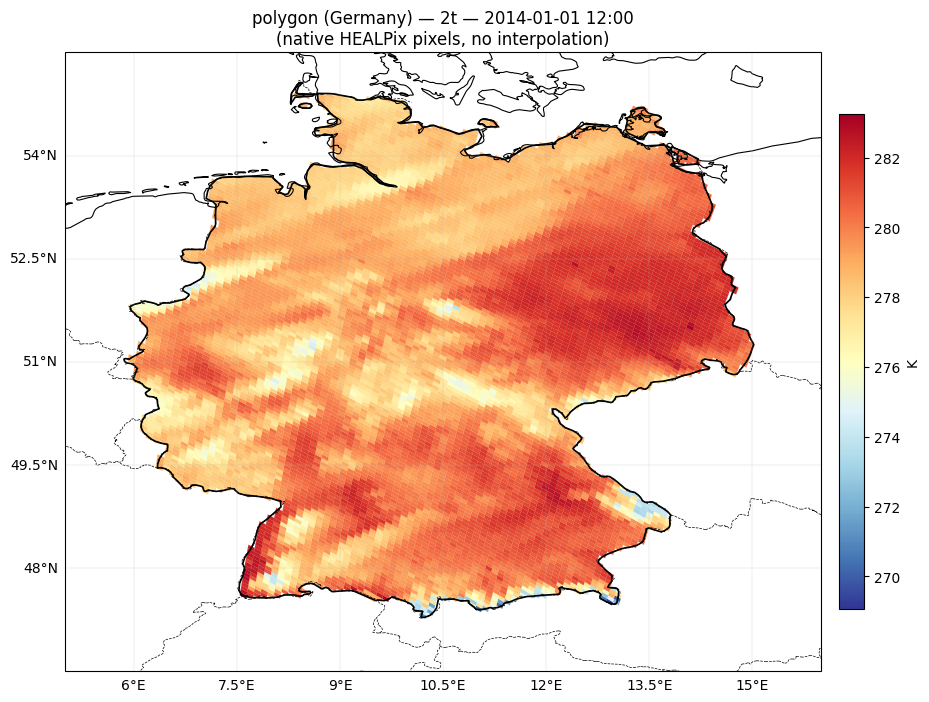

In [ ]:
nside = store_high.nside
da = poly_result["2t"].squeeze()
lats = poly_result.coords["latitude"].values
lons = poly_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

n_steps = 50
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(plt.cm.RdYlBu_r)
coll.set_norm(norm)
ax.add_collection(coll)

# Overlay country outline from earthkit-geo shapes
for shape in shapes:
    s_lons = [pt[1] for pt in shape]
    s_lats = [pt[0] for pt in shape]
    ax.plot(s_lons, s_lats, color="black", linewidth=1.2, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([5, 16, 46.5, 55.5])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title(f"polygon ({COUNTRY}) — 2t — 2014-01-01 12:00\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

## Area subsetting with MARS keywords + server-side regridding

`area=(north, west, south, east)` returns data on a regular lat/lon grid (server-side interpolation).
Good choices are `grid="0.25/0.25"` for standard resolution and `grid="0.05/0.05"` for high-resolution data. You can use any other regular grid to control the output resolution.

> **See also:** [climate-dt-earthkit-area-example.ipynb](../full-field/climate-dt-earthkit-area-example.ipynb) · [climate-dt-earthkit-aoi-example.ipynb](../full-field/climate-dt-earthkit-aoi-example.ipynb) · [climate-dt-earthkit-serverside-interpolation.ipynb](../full-field-post-processing/climate-dt-earthkit-serverside-interpolation.ipynb)

In [ ]:
# Area subset over Central Europe — 24 hourly steps
area_hourly = ds_high["2t"].polytope.sel(
    model="ICON",
    time=slice("2014-01-01T00:00", "2014-01-01T23:00"),
    area=(55, 5, 47, 15),   # (north, west, south, east)
    #grid="0.05/0.05",      # default for high resolution
)
area_hourly

  🌍 area request for 2t (20140101/to/20140101, area=55/5/47/15, grid=0.05/0.05)


<xarray.Dataset> Size: 6MB
Dimensions:    (time: 24, latitude: 161, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 192B 2014-01-01 ... 2014-01-01T23:00:00
  * latitude   (latitude) float64 1kB 55.0 54.95 54.9 54.85 ... 47.1 47.05 47.0
  * longitude  (longitude) float64 2kB 5.0 5.05 5.1 5.15 ... 14.9 14.95 15.0
Data variables:
    2t         (time, latitude, longitude) float64 6MB ...
Attributes:
    param:        2t
    paramId:      167
    class:        d1
    stream:       clte
    levtype:      sfc
    type:         fc
    expver:       0001
    date:         20140101
    time:         0
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF

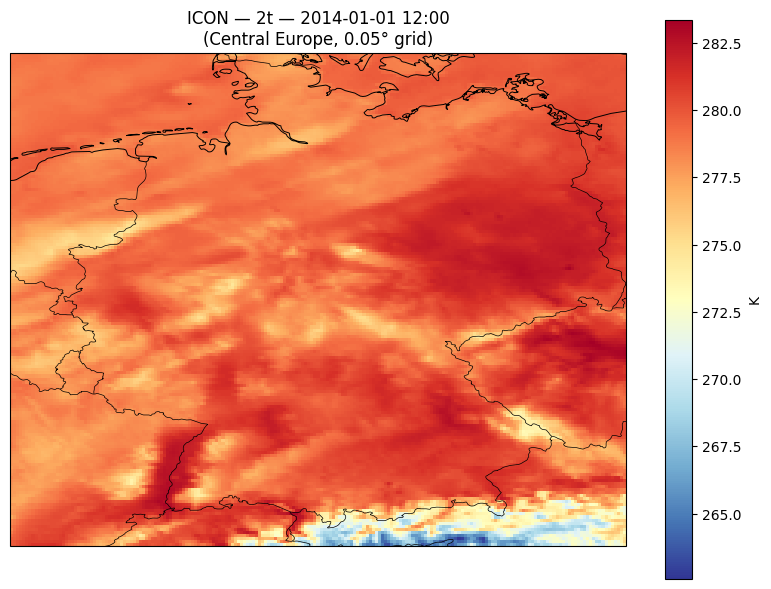

In [ ]:
var_name = list(area_hourly.data_vars)[0]
field_noon = area_hourly[var_name].sel(time="2014-01-01T12:00")

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(8, 6))
field_noon.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdYlBu_r",
                cbar_kwargs={"label": "K"})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.set_title(f"ICON — {var_name} — 2014-01-01 12:00\n(Central Europe, 0.05° grid)")
plt.tight_layout()
plt.show()

## Notes

- **Automatic batching:** use `.polytope.sel(time=slice(...))` to auto-batch Polytope requests over the requested date range.
- **SFC variable names:** instantaneous fields use standard ECMWF shortNames (`2t`, `sp`, `10si`), while hourly-mean fluxes keep the `avg_` prefix (`avg_tprate`, `avg_ishf`).
- **Ocean/ice (o2d, o3d):** daily resolution, all variables keep `avg_` prefix.
- `store.clear_cache()` frees memory from previously fetched fields.

In [ ]:
# Free memory if needed
store.clear_cache()
daily_store.clear_cache()
story_store.clear_cache()
store_high.clear_cache()